In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    EncodingType,
    PositionAxis,
)
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.visualization import plot_wavefunction

### Initial parameters


In [2]:
# beam parameters
vacuum_wavelength = 1e-6
beam_FWHM = 5e-3 * 1e-2

# lens parameters
focal_length = 200e-3 * 1e-2
# lens_diameter = 25e-3
lens_diameter = 50e-3 * 1e-2
refractive_index = 1.5

# free space propagation parameters
propagation_after_lens = 1.5 * focal_length

# simulation parameters
transverse_length = 100e-3 * 1e-2  # transverse simulation window
num_of_steps_after_lens = 10
lens_slices = 100
num_qubits = 10
max_delta = 0.01

### Constants


In [3]:
c = constants.c
# hbar = constants.hbar

### Derived parameters


In [4]:
# geometry
radius_of_curvature = focal_length * (refractive_index - 1)
lens_radius = lens_diameter / 2
lens_thickness = radius_of_curvature - np.sqrt(radius_of_curvature**2 - lens_radius**2)


k_0 = 2 * constants.pi / vacuum_wavelength
reduced_wavelength = vacuum_wavelength / refractive_index

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / np.sqrt(2 * np.log(2))
# gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

# vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength

lens_slice_thickness = lens_thickness / lens_slices
step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

In [5]:
print(delta_x, vacuum_wavelength)

9.765625e-07 1e-06


In [6]:
x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
twos_complement_x_axis = PositionAxis(
    num_qubits=num_qubits,
    delta_x=delta_x,
    encoding=EncodingType.TWOS_COMPLEMENT_MIRRORED,
)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

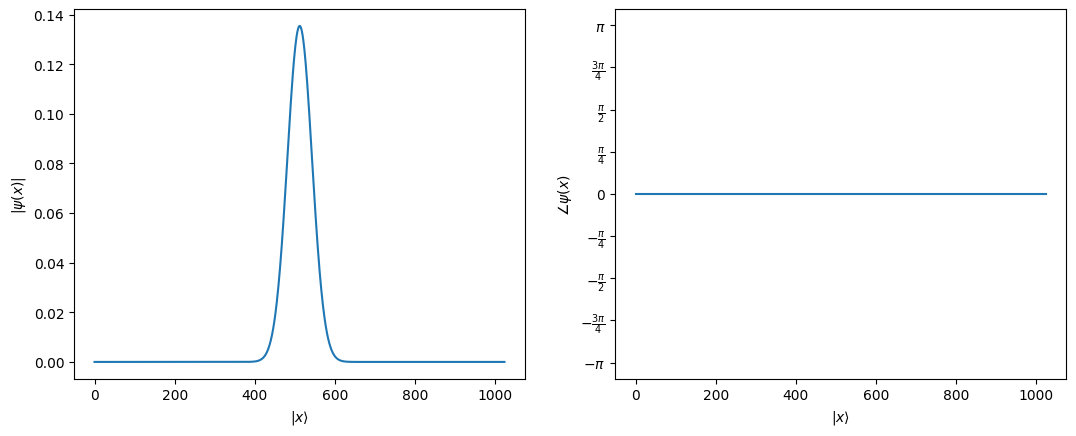

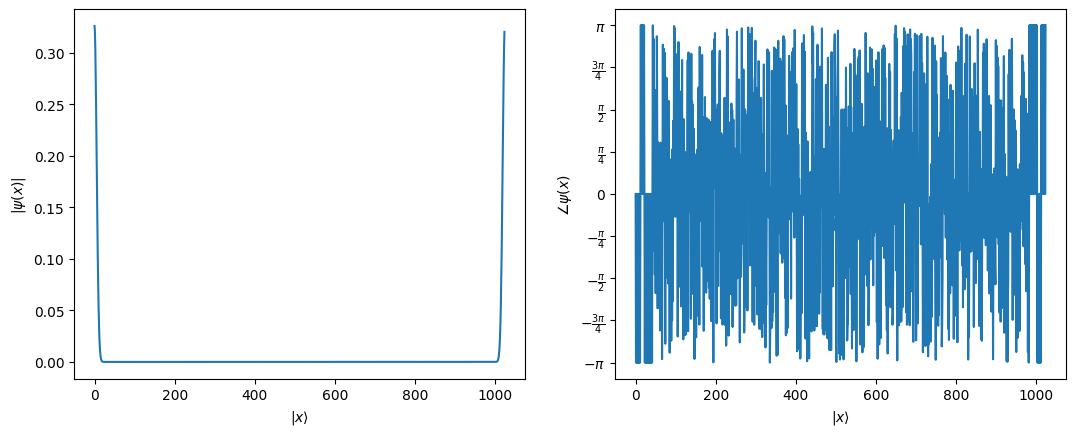

In [7]:
initial_wavefunction = gaussian_signal(
    x_axis,
    gaussian_beam_waist,
    gaussian_mean,
)
plot_wavefunction(initial_wavefunction.data)
plot_wavefunction(np.fft.fft(initial_wavefunction.data, norm="ortho"))

A lens applies a phase as

$$
e^{-ik_0\frac{x^2}{2f}}
$$


-262143.99999999994


(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

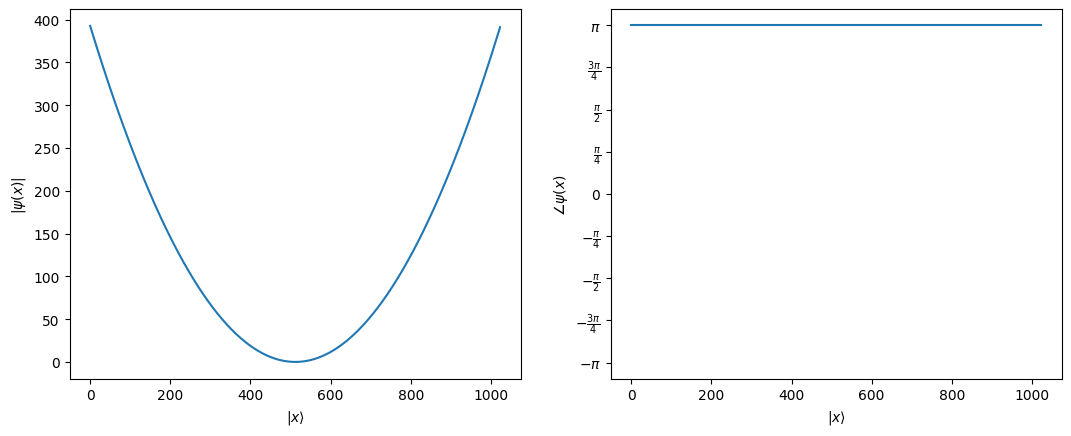

In [8]:
from qiskit_signals.quantum_signal import PolynomialQuantumSignal

lens_signal = PolynomialQuantumSignal(
    axis=twos_complement_x_axis, alpha=-k_0 / 2 / focal_length, power=2
)

print((lens_signal.data / k_0 * 2 * focal_length / delta_x**2).min())
# plot_wavefunction(
#     lens_signal.data / k_0 * 2 * focal_length / delta_x**2, normalize=False
# )
plot_wavefunction(lens_signal.data, normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

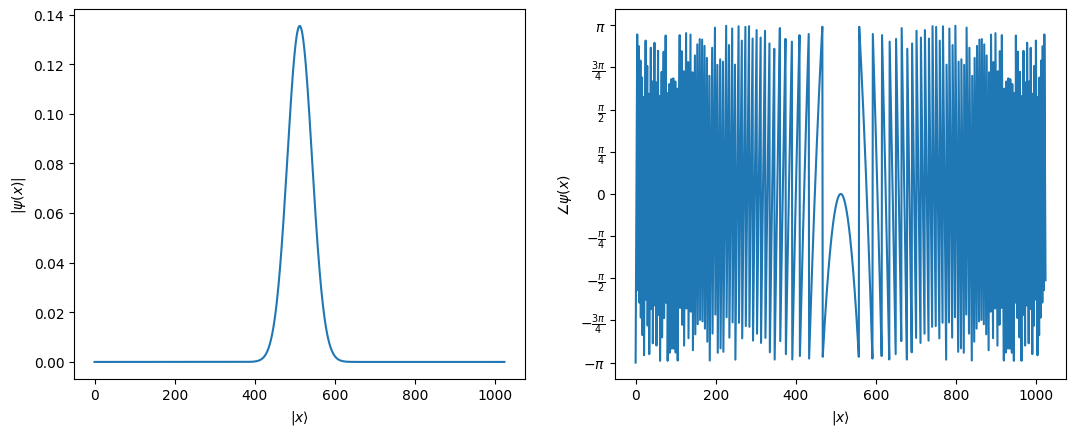

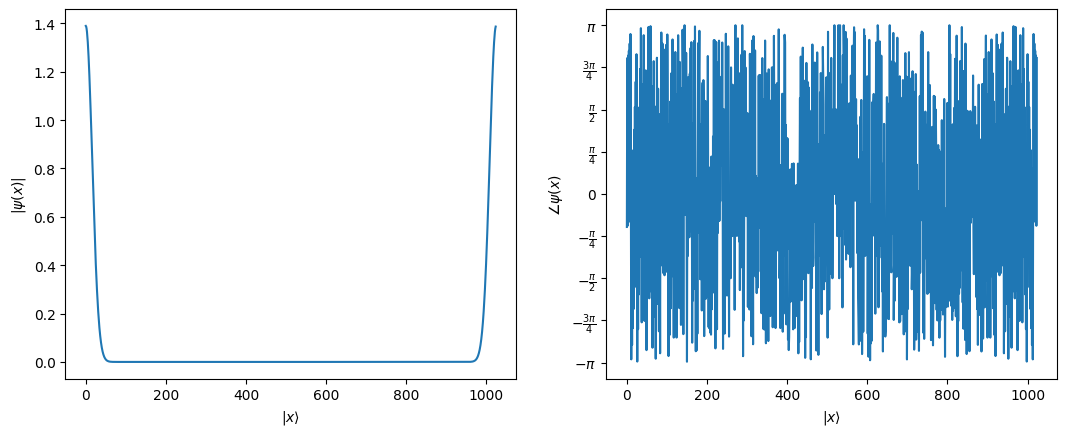

In [9]:
wavefront_after_lens = initial_wavefunction.data * np.exp(1j * lens_signal.data)
plot_wavefunction(wavefront_after_lens)
plot_wavefunction(np.fft.fft(wavefront_after_lens, norm="ortho"), normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

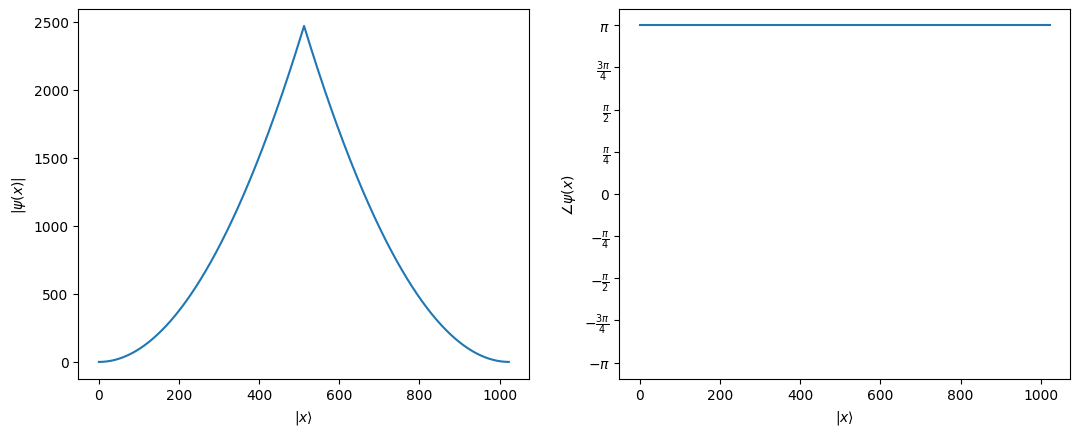

In [10]:
from wave_optics_propagation.elements import free_space_signal_generator

free_space_signal = free_space_signal_generator(
    k_axis,
    delta_t=propagation_after_lens / constants.c,
    wavelength=vacuum_wavelength,
    c=constants.c,
)

plot_wavefunction(free_space_signal.data, normalize=False)

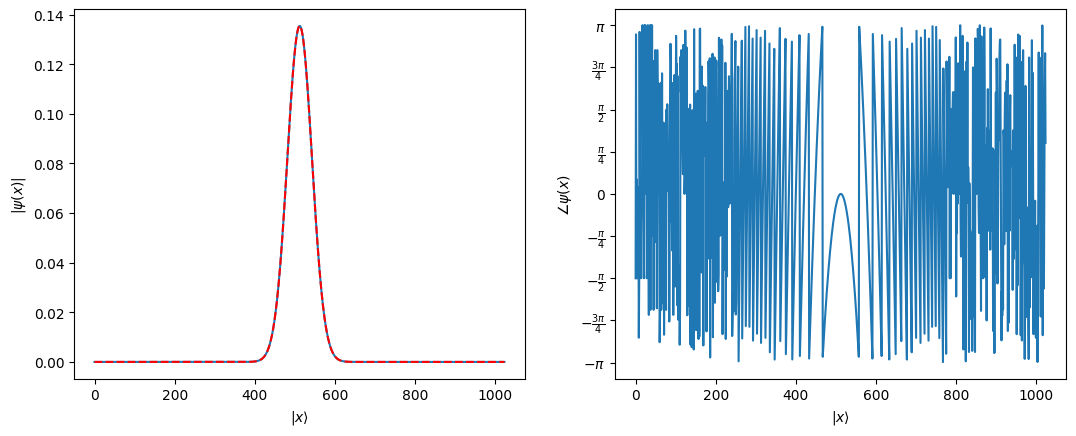

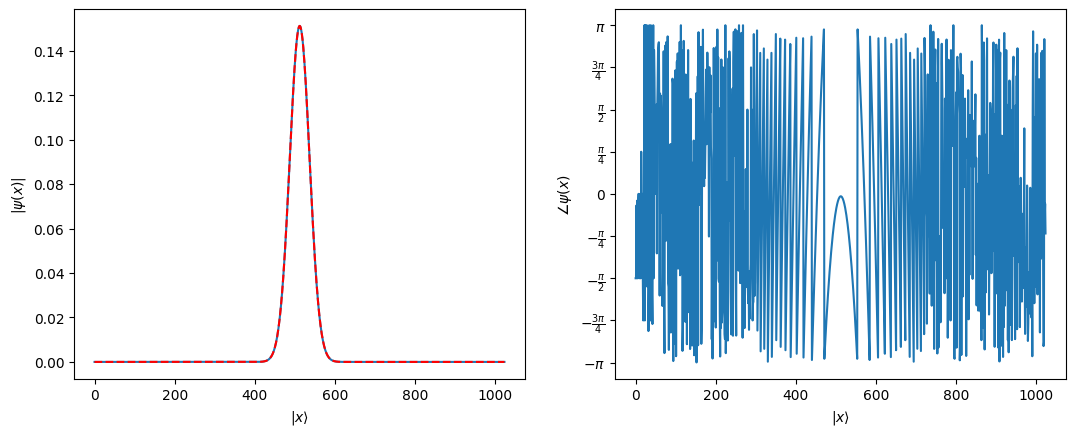

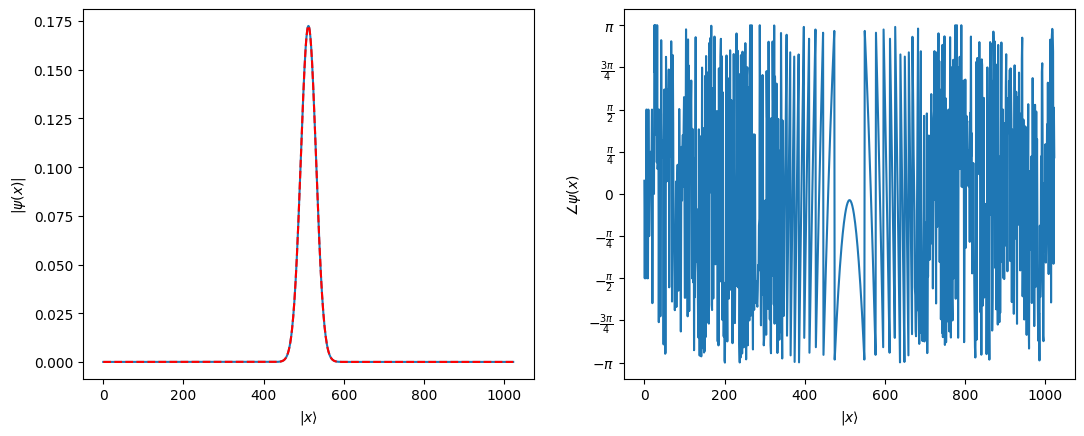

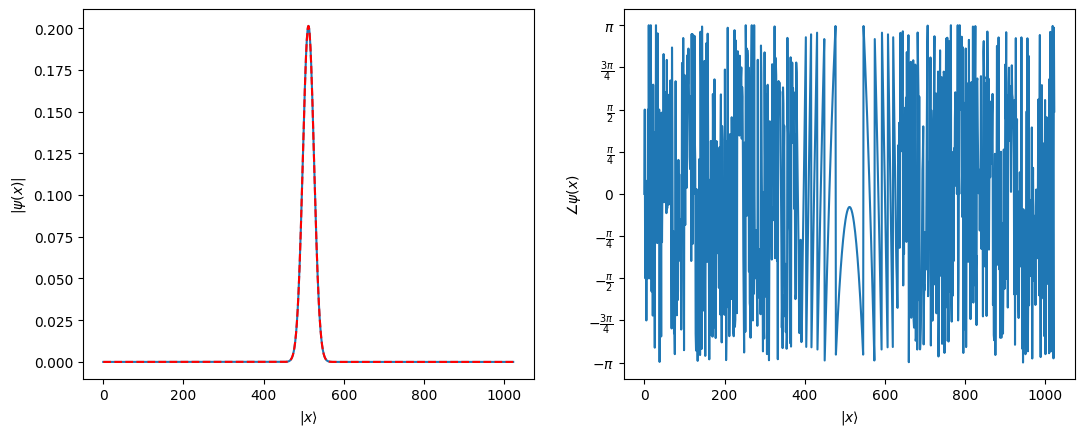

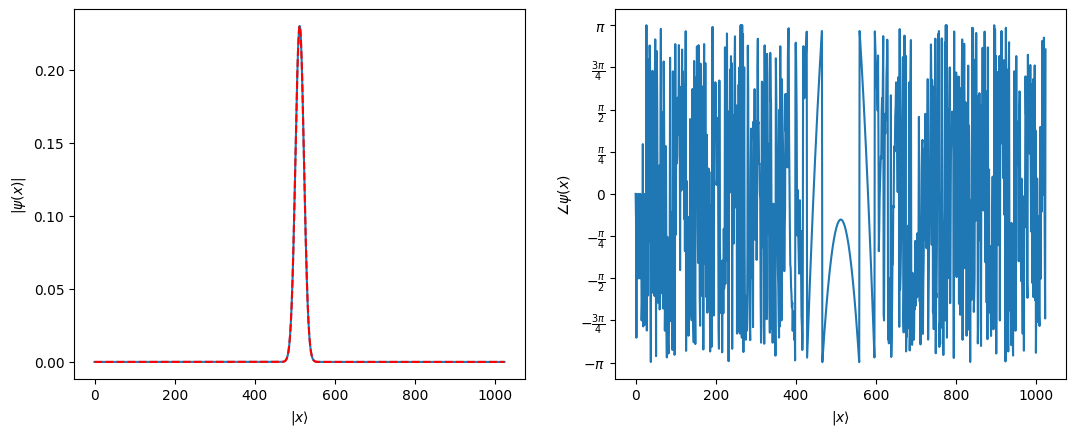

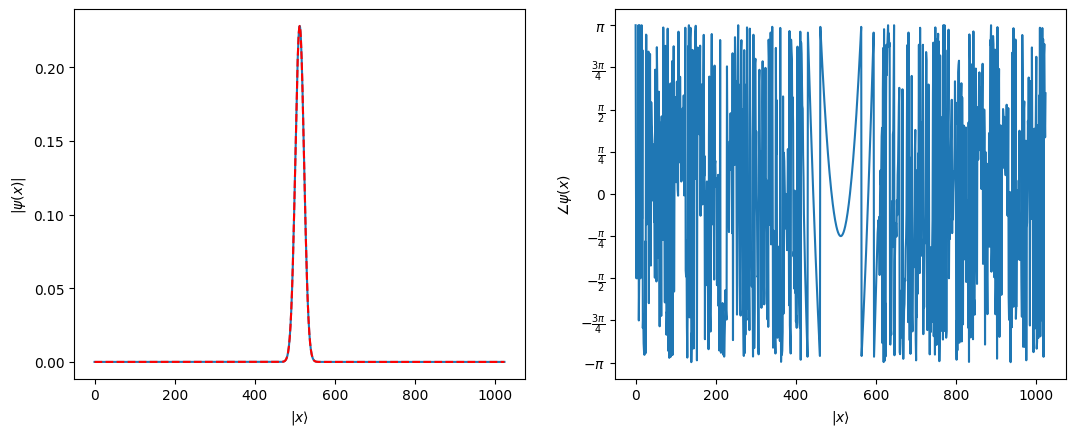

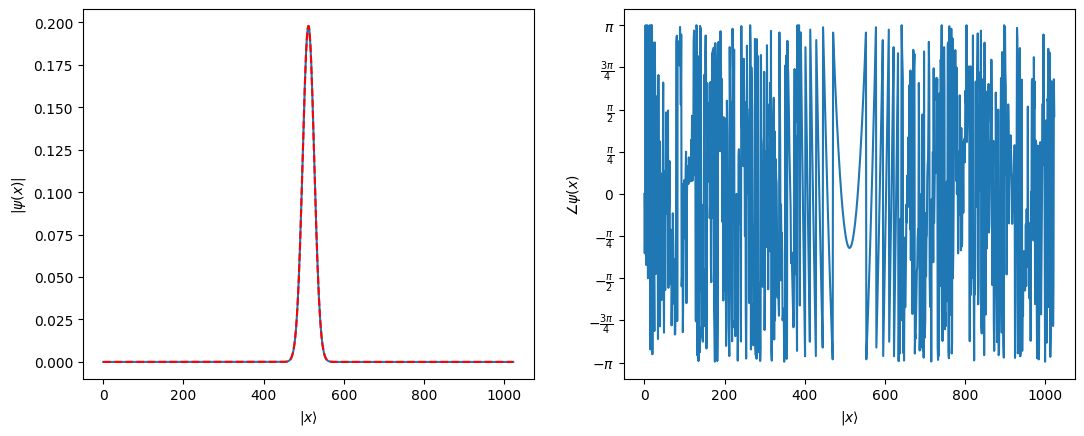

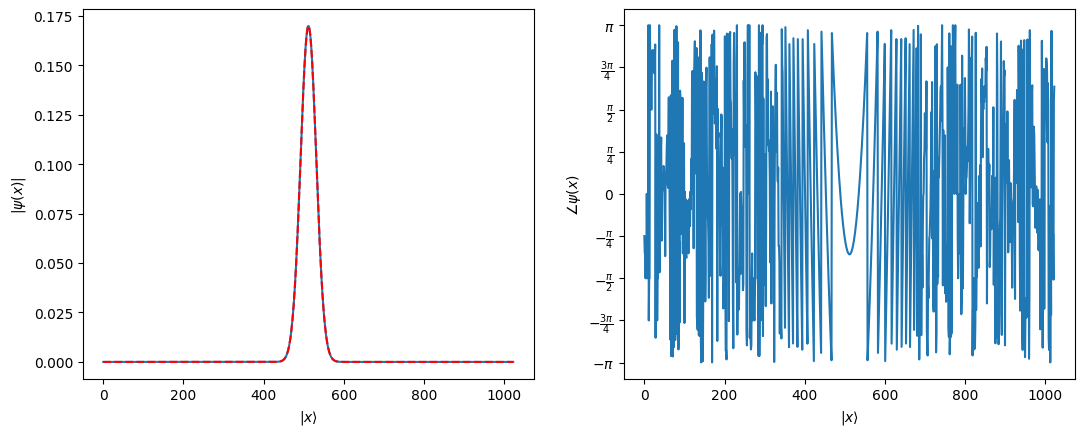

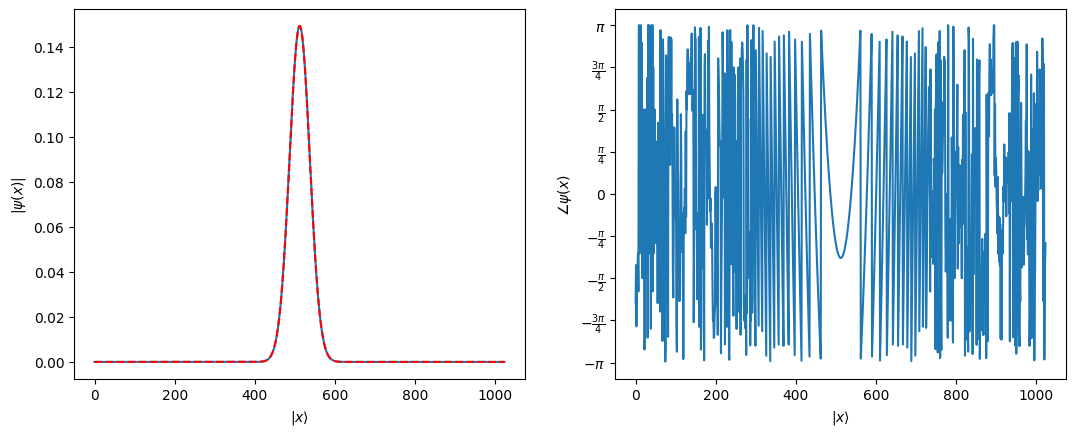

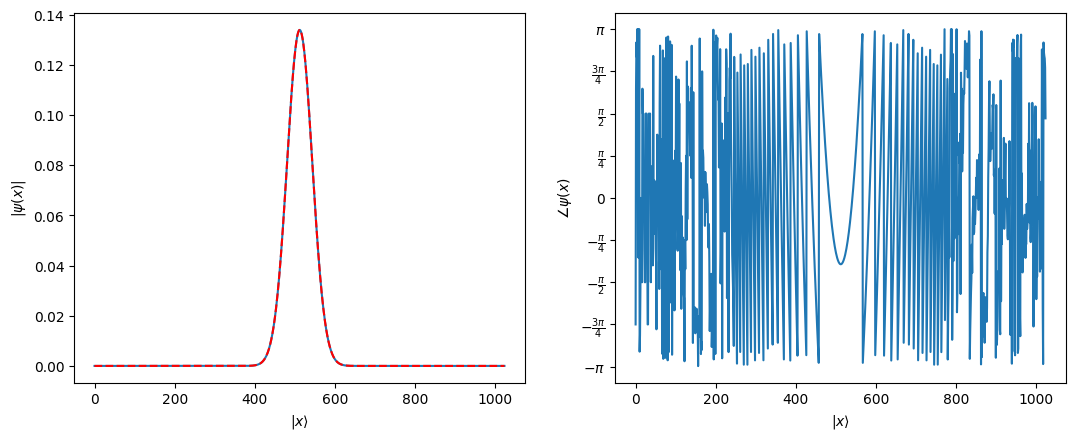

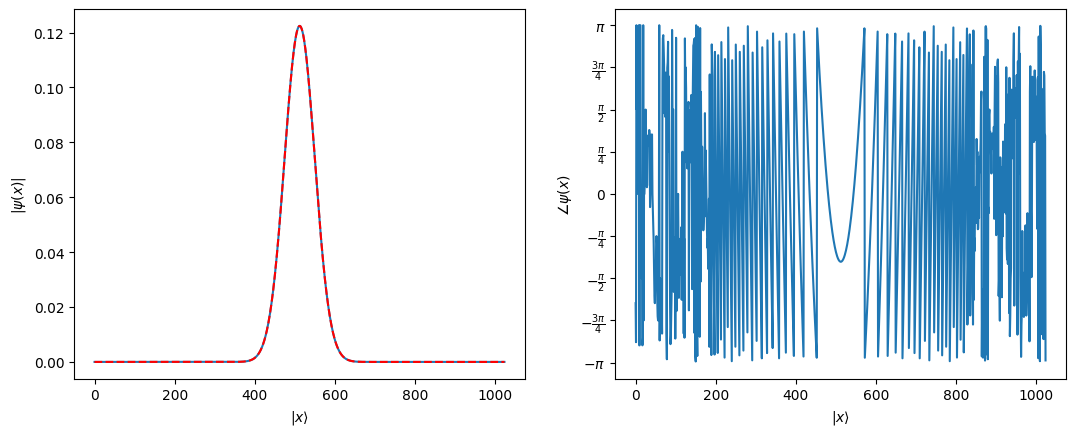

In [11]:
zs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]) * focal_length
for z in zs:
    free_space_signal = free_space_signal_generator(
        k_axis,
        delta_t=z / constants.c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )

    fourier_transformed = np.fft.fft(wavefront_after_lens.data, norm="ortho")
    propagated = fourier_transformed * np.exp(1j * free_space_signal.data)
    inverse_fourier_transformed = np.fft.ifft(propagated, norm="ortho")

    fig, (ax1, ax2) = plot_wavefunction(inverse_fourier_transformed)

    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist,
        z,
        focal_length,
        vacuum_wavelength,
        1,
    )

    signal_with_lens = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(signal_with_lens.data / np.linalg.norm(signal_with_lens.data), "r--")